In [1]:
# === ПРОЕКТ: Аналітика меблевого виробництва ===
# Автор: [Твоє ім'я]
# Ціль: Передбачити ціну меблів за допомогою Machine Learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

print("✅ Всі бібліотеки завантажено успішно!")
print("🪑 Починаємо аналіз меблевого виробництва!")

✅ Всі бібліотеки завантажено успішно!
🪑 Починаємо аналіз меблевого виробництва!


In [2]:
# ІМПОРТИ — без них нічого не працює!
import pandas as pd
import numpy as np

print("✅ Бібліотеки завантажено!")

# СТВОРЮЄМО ДАНІ
np.random.seed(42)
n = 200

data = {
    'тип': np.random.choice(['шафа', 'стіл', 'ліжко', 'комод', 'тумба'], n),
    'матеріал': np.random.choice(['ДСП', 'МДФ', 'масив_дуба', 'масив_сосни'], n),
    'ширина_см': np.random.randint(40, 250, n),
    'висота_см': np.random.randint(40, 220, n),
    'глибина_см': np.random.randint(30, 80, n),
    'має_фурнітуру_преміум': np.random.choice([0, 1], n),
    'час_виробництва_годин': np.random.randint(2, 40, n),
}

df = pd.DataFrame(data)

base_prices = {'шафа': 5000, 'стіл': 3000, 'ліжко': 6000, 'комод': 4000, 'тумба': 2000}
material_mult = {'ДСП': 1.0, 'МДФ': 1.4, 'масив_сосни': 1.8, 'масив_дуба': 2.5}

df['ціна_грн'] = df.apply(lambda row: 
    base_prices[row['тип']] * material_mult[row['матеріал']] 
    + row['ширина_см'] * 15 
    + row['висота_см'] * 10
    + row['має_фурнітуру_преміум'] * 1500
    + row['час_виробництва_годин'] * 100
    + np.random.randint(-500, 500), axis=1)

print(f"📊 Створено {len(df)} записів")
print(f"💰 Ціни від {df['ціна_грн'].min():.0f} до {df['ціна_грн'].max():.0f} грн")
print()
print(df.head(10))

✅ Бібліотеки завантажено!
📊 Створено 200 записів
💰 Ціни від 5270 до 24960 грн

     тип     матеріал  ширина_см  висота_см  глибина_см  \
0  комод          МДФ        190        177          52   
1  тумба          МДФ        233        140          66   
2  ліжко          МДФ        166        191          66   
3  тумба   масив_дуба        194        216          39   
4  тумба   масив_дуба        169        138          39   
5   стіл  масив_сосни         56         75          48   
6  ліжко  масив_сосни        143        135          46   
7  ліжко          ДСП        200        191          50   
8  ліжко          ДСП        176        190          43   
9  тумба  масив_сосни         82         76          38   

   має_фурнітуру_преміум  час_виробництва_годин  ціна_грн  
0                      0                     28   12756.0  
1                      0                     34   10875.0  
2                      0                      5   13158.0  
3                      1       

C:\Users\HP\AppData\Local\Temp\ipykernel_23764\909962224.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='тип', y='ціна_грн', palette='Set2', ax=axes[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_23764\909962224.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='матеріал', y='ціна_грн', palette='viridis', ax=axes[1])


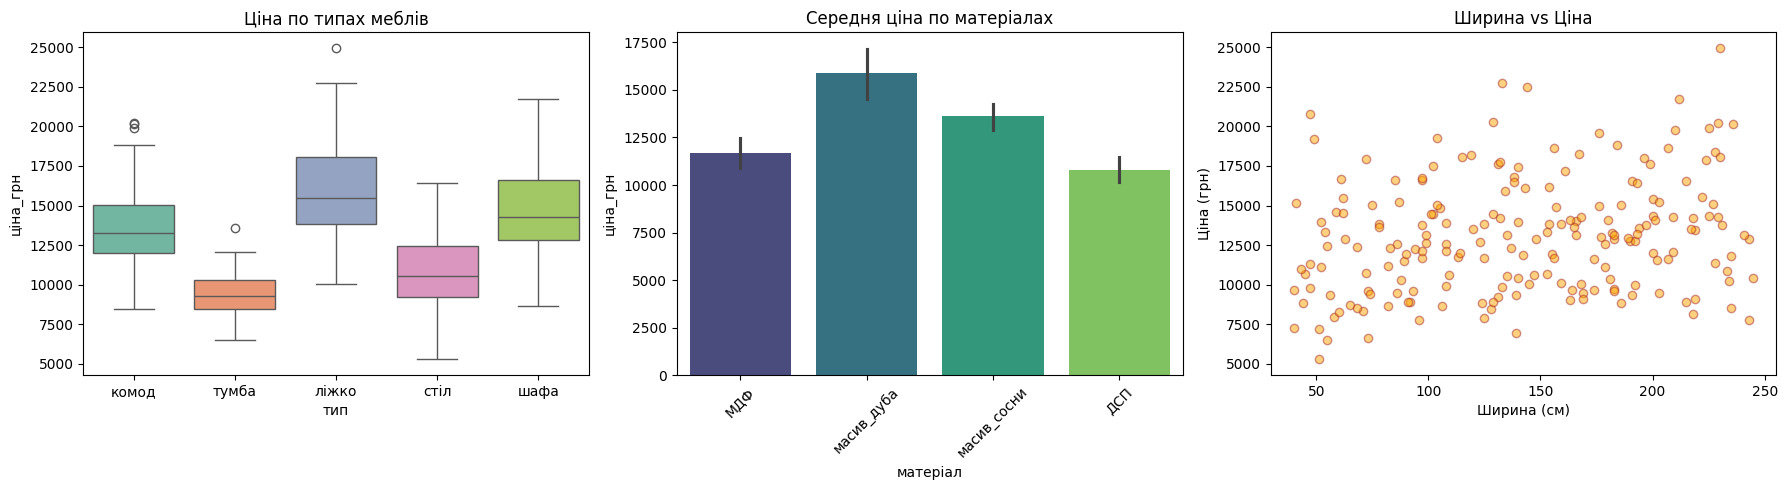

✅ Графіки збережено у файл grafiky_mebli.png!

🏋️ Тренувальних: 160 | 🧪 Тестових: 40

🏆 РЕЗУЛЬТАТИ МОДЕЛЕЙ:

📌 Linear Regression:
   Середня помилка: 2245 грн
   Точність R²:    36.4%

📌 Random Forest:
   Середня помилка: 1078 грн
   Точність R²:    85.9%

📌 Gradient Boosting:
   Середня помилка: 876 грн
   Точність R²:    88.3%

🥇 ПЕРЕМОЖЕЦЬ: Gradient Boosting — точність 88.3%!

🔮 ПЕРЕДБАЧАЄМО ЦІНУ НОВИХ МЕБЛІВ:

   🪑 Шафа | масив дуба | преміум | 180x200x60
   💰 Передбачена ціна: 17,099 грн

   🪑 Стіл | МДФ | стандарт | 120x75x70
   💰 Передбачена ціна: 9,804 грн

   🪑 Ліжко | ДСП | преміум | 160x45x200
   💰 Передбачена ціна: 13,656 грн


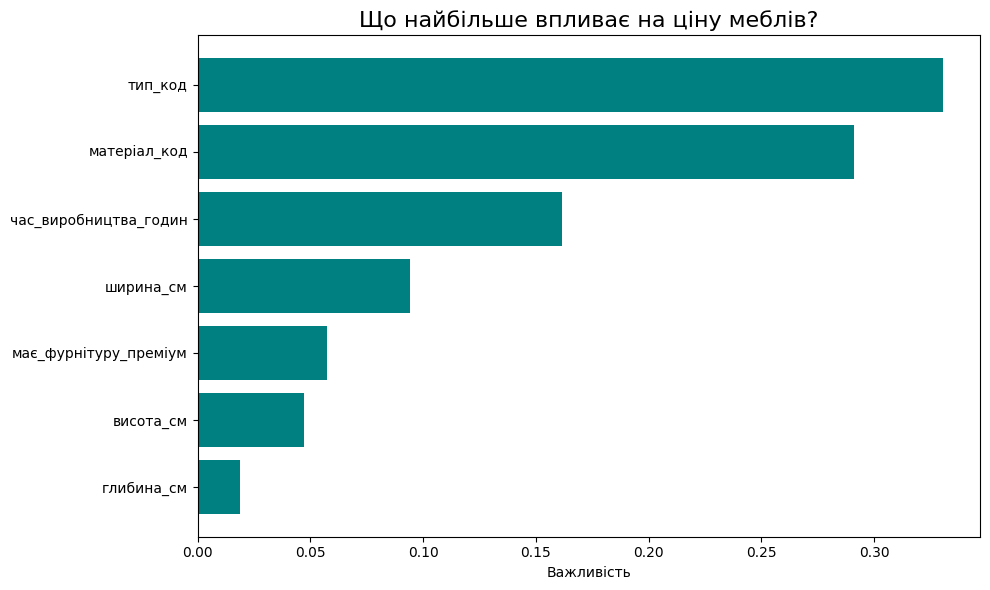


🏆 Найважливіший фактор: тип_код (33.0%)

🎉 ПРОЕКТ ЗАВЕРШЕНО! ТИ ЗРОБИВ ЦЕ!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# ============================================
# 📊 ЧАСТИНА 2: ВІЗУАЛІЗАЦІЯ
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Графік 1: Ціна по типах
sns.boxplot(data=df, x='тип', y='ціна_грн', palette='Set2', ax=axes[0])
axes[0].set_title('Ціна по типах меблів')

# Графік 2: Ціна по матеріалах
sns.barplot(data=df, x='матеріал', y='ціна_грн', palette='viridis', ax=axes[1])
axes[1].set_title('Середня ціна по матеріалах')
axes[1].tick_params(axis='x', rotation=45)

# Графік 3: Ширина vs Ціна
axes[2].scatter(df['ширина_см'], df['ціна_грн'], alpha=0.5, c='orange', edgecolors='brown')
axes[2].set_title('Ширина vs Ціна')
axes[2].set_xlabel('Ширина (см)')
axes[2].set_ylabel('Ціна (грн)')

plt.tight_layout()
plt.savefig('grafiky_mebli.png', dpi=150)
plt.show()
print("✅ Графіки збережено у файл grafiky_mebli.png!")

# ============================================
# 🤖 ЧАСТИНА 3: MACHINE LEARNING
# ============================================

# Кодуємо текст в числа
le_type = LabelEncoder()
le_material = LabelEncoder()
df['тип_код'] = le_type.fit_transform(df['тип'])
df['матеріал_код'] = le_material.fit_transform(df['матеріал'])

# Ознаки та ціль
features = ['тип_код', 'матеріал_код', 'ширина_см', 'висота_см',
            'глибина_см', 'має_фурнітуру_преміум', 'час_виробництва_годин']

X = df[features]
y = df['ціна_грн']

# Розділяємо дані
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n🏋️ Тренувальних: {len(X_train)} | 🧪 Тестових: {len(X_test)}")

# Тренуємо 3 моделі
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print("\n" + "=" * 50)
print("🏆 РЕЗУЛЬТАТИ МОДЕЛЕЙ:")
print("=" * 50)

best_model = None
best_score = -1

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    print(f"\n📌 {name}:")
    print(f"   Середня помилка: {mae:.0f} грн")
    print(f"   Точність R²:    {r2*100:.1f}%")
    
    if r2 > best_score:
        best_score = r2
        best_model = (name, model)

print(f"\n🥇 ПЕРЕМОЖЕЦЬ: {best_model[0]} — точність {best_score*100:.1f}%!")

# ============================================
# 🔮 ЧАСТИНА 4: ПЕРЕДБАЧЕННЯ НОВИХ МЕБЛІВ
# ============================================

print("\n" + "=" * 50)
print("🔮 ПЕРЕДБАЧАЄМО ЦІНУ НОВИХ МЕБЛІВ:")
print("=" * 50)

new_furniture = pd.DataFrame({
    'тип_код': le_type.transform(['шафа', 'стіл', 'ліжко']),
    'матеріал_код': le_material.transform(['масив_дуба', 'МДФ', 'ДСП']),
    'ширина_см': [180, 120, 160],
    'висота_см': [200, 75, 45],
    'глибина_см': [60, 70, 200],
    'має_фурнітуру_преміум': [1, 0, 1],
    'час_виробництва_годин': [20, 8, 15],
})

names = [
    "Шафа | масив дуба | преміум | 180x200x60",
    "Стіл | МДФ | стандарт | 120x75x70",
    "Ліжко | ДСП | преміум | 160x45x200",
]

prices = best_model[1].predict(new_furniture)

for name, price in zip(names, prices):
    print(f"\n   🪑 {name}")
    print(f"   💰 Передбачена ціна: {price:,.0f} грн")

# ============================================
# 📊 ЧАСТИНА 5: ЩО ВПЛИВАЄ НА ЦІНУ?
# ============================================

importance = pd.DataFrame({
    'Фактор': features,
    'Важливість': best_model[1].feature_importances_
}).sort_values('Важливість', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['Фактор'], importance['Важливість'], color='teal')
plt.title('Що найбільше впливає на ціну меблів?', fontsize=16)
plt.xlabel('Важливість')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

top = importance.iloc[-1]
print(f"\n🏆 Найважливіший фактор: {top['Фактор']} ({top['Важливість']*100:.1f}%)")
print("\n" + "=" * 50)
print("🎉 ПРОЕКТ ЗАВЕРШЕНО! ТИ ЗРОБИВ ЦЕ!")
print("=" * 50)